In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

In [ ]:
!pip install ecos
!pip install scs

In [1]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# --- Hàm xây dựng Ma trận A (từ Ảnh 2) ---
def build_A_matrix(n_chargers: int, n_slots: int) -> np.ndarray:
    """
    Xây dựng ma trận ràng buộc A (slot-matrix constraint)
    Kích thước: (n_slots, n_chargers * n_slots)
    """
    # 1. Tạo ma trận đơn vị I_T (kích thước T x T)
    I_T = np.eye(n_slots)

    # 2. Lặp lại (tile) ma trận I_T C lần theo chiều ngang (1, C)
    A = np.tile(I_T, (1, n_chargers))

    return A

In [ ]:
def buyer_best_response_cvx(v_i: np.ndarray,
                            p: np.ndarray,
                            A: np.ndarray,
                            q_i,
                            B_i: float) -> np.ndarray:
    """
    CVXPY solve of
        max  log(v_i · x)
        s.t. x >= 0 , (price + q_i)ᵀ x <= B_i
    """
    m = len(v_i) # Số lượng hàng hóa (n_goods)

    # Định nghĩa biến tối ưu
    x = cp.Variable(m, nonneg=True)

    # 1. Hàm mục tiêu (Objective)
    # Thêm B_i * bên ngoài log, theo Công thức 9
    utility = v_i @ x + 1e-12  # v_i · x (thêm 1e-12 để tránh log(0))
    objective = cp.Maximize(B_i * cp.log(utility))

    # 2. Ràng buộc ngân sách (Constraint)
    # Đây là "giá hiệu dụng" (effective price) mới
    effective_price = p + (A.T @ q_i)
    constraint = [effective_price @ x <= B_i]

    # 3. Giải bài toán
    prob = cp.Problem(objective, constraint)
    try:
        prob.solve(solver="ECOS", warm_start=True)
    except cp.SolverError:
        prob.solve(solver="SCS")

    return x.value

In [ ]:
from google.colab import drive

# BƯỚC 1: Kết nối Google Drive (chỉ cần chạy 1 lần)
drive.mount('/content/drive', force_remount=True)

# BƯỚC 2: Cập nhật đường dẫn FACTOR_DIR
# Giả sử bạn đặt thư mục "valuation_out_23h_sigmoid"
# ngay trong "My Drive" (Drive của tôi)
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_50u_60i"

# --- Code của bạn bắt đầu từ đây ---
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

# --- Phần còn lại của code giữ nguyên ---
n_buyers, n_goods = valuations.shape
budgets = np.full(n_buyers, 1.0)
energy  = np.ones(n_buyers)
p0      = np.ones(n_goods)
n_slots = 10
q0 = np.ones((n_buyers, n_slots))
b_constraint = np.ones((n_buyers, n_slots))

obj_tol = 1e-3
num_iters = 10 ** 100
log_freq  = 100
X_tol   = 1e-5
seed = 2001
timE = 7200

print(f"\nThiết lập hoàn tất. (n_buyers={n_buyers}, n_goods={n_goods})")

Mounted at /content/drive
✓ Đã tải xong factors. Ma trận Valuations có shape: (50, 60)

Thiết lập hoàn tất. (n_buyers=50, n_goods=60)


In [ ]:
# --- BẠN BẮT ĐẦU TỪ ĐÂY ---

# 1. Giả sử bạn đã tải 'valuations'
# valuations = np.load(...)

# 2. Lấy n_goods từ valuations
n_buyers, n_goods = valuations.shape

# 3. Định nghĩa n_slots (từ ảnh của bạn)
n_slots = 10

# 4. Tính toán n_chargers
# (Kiểm tra xem n_goods có chia hết cho n_slots không)
if n_goods % n_slots != 0:
    print(f"⚠️ Cảnh báo: n_goods ({n_goods}) không chia hết cho n_slots ({n_slots})")

n_chargers = n_goods // n_slots

# 5. --- TẠO MA TRẬN A ĐỂ TRUYỀN VÀO HÀM ---
A_matrix = build_A_matrix(n_chargers, n_slots)

print(f"Đã tạo Ma trận A với shape: {A_matrix.shape}")

Đã tạo Ma trận A với shape: (10, 60)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_constraint_violation(
    hist_base,
    hist_full,
    log_freq=1,
    title="Constraint Satisfaction Convergence",
    y_label=r'||Max(0, Ax - b)||_inf',
    xlim=None,
    ylim=None
):
    """
    Vẽ biểu đồ so sánh mức độ vi phạm ràng buộc giữa Baseline và Proposed Full Gradient.
    """

    plt.figure(figsize=(10, 6))

    # 1. Tạo trục X
    x_axis = np.arange(len(hist_base)) * log_freq

    # 2. Vẽ Baseline (Màu xám, nét đứt)
    plt.plot(x_axis, hist_base,
             color='gray', linestyle='--', linewidth=2.5, alpha=0.8,
             label='Baseline (Eisenberg-Gale)')

    # 3. Vẽ Proposed Full (Màu xanh lá, nét liền)
    plt.plot(x_axis, hist_full,
             color='#008000', linestyle='-', linewidth=3.0, alpha=0.9,
             label='Proposed Method')

    # 4. Trang trí biểu đồ
    # Đường an toàn y=0
    plt.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.4)

    # Chú thích vùng
    # Lấy giới hạn trục Y hiện tại hoặc mặc định để đặt text cho đẹp
    y_text_pos = ylim[1] * 0.05 if ylim else 0.5


    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)

    # Zoom trục X nếu cần
    if xlim:
        plt.xlim(0, xlim)

    # Zoom trục Y để cắt bỏ phần "bùng nổ" ban đầu
    if ylim:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.show()

In [ ]:
import time
import numpy as np
np.seterr(all='ignore') # Tắt cảnh báo log(0)

import time
import numpy as np

def one_sample_sgd(
    A: np.ndarray,
    b: np.ndarray,
    supply_s: np.ndarray,
    q0: np.ndarray,
    valuations: np.ndarray,
    budgets: np.ndarray,
    p0: np.ndarray,
    lr_p=0.05, lr_q=0.05,
    num_iters=500,      # SGD cần nhiều bước hơn
    seed=0,
    log_freq=10,         # Log thường xuyên hơn
    update_q=True        # Tham số bật/tắt Baseline
):
    rng = np.random.default_rng(seed)
    n, m = valuations.shape
    T = A.shape[0]

    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    if not update_q:
        q = np.zeros_like(q)

    # Warm-start X (để tính D ban đầu)
    X = np.zeros((n, m))
    for j in range(n):
        # Lưu ý: Hàm solver phải xử lý được effective_price = p + A.T @ q
        X[j] = buyer_best_response_cvx(valuations[j], p, A, q, budgets[j])

    # Tổng cầu ban đầu
    D = X.sum(axis=0)

    metric_hist = [] # Lưu Mean Residual

    for t in range(1, num_iters + 1):
        # 1. Chọn user ngẫu nhiên & Cập nhật D
        i = int(rng.integers(n))
        D -= X[i]

        x_i_new = buyer_best_response_cvx(valuations[i], p, A, q, budgets[i])
        if x_i_new is None: x_i_new = X[i]

        X[i] = x_i_new
        D += x_i_new

        # 2. Tính Load hiện tại (Incremental)
        current_load = A @ D

        # 3. Cập nhật biến (Stochastic Gradient)
        # Gradient p: Demand - Supply
        g_p = D - supply_s
        # Gradient q: Load - Capacity (b)
        g_q_update = current_load - b

        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        p = np.maximum(p + alpha * g_p, 0.0)

        if update_q:
            q = np.maximum(q + beta * g_q_update, 0.0)

        # 4. Log Metric (Mean Residual)
        if t % log_freq == 0:
            # Metric: Mean(Ax - b)
            # Dương = Quá tải, Âm = Dư thừa
            residual = current_load - b
            mean_residual = np.mean(residual)
            metric_hist.append(mean_residual)

    return metric_hist

In [ ]:
import numpy as np
import cvxpy as cp
import time
np.seterr(all='ignore') # Tắt cảnh báo log(0)

def full_grad_descent(
    A: np.ndarray,      # Dùng để chạy thuật toán (Gradient)
    b: np.ndarray,      # Dùng để chạy thuật toán (Gradient)
    supply_s: np.ndarray,
    q0: np.ndarray,
    valuations: np.ndarray,
    budgets: np.ndarray,
    p0: np.ndarray,
    lr_p=0.05, lr_q=0.05,
    num_iters=500,
    log_freq=1,
    update_q=True,
    # --- THAM SỐ MỚI ĐỂ VẼ CHART ---
    A_true=None,        # Ma trận thật để tính violation
    b_true=None         # Capacity thật để tính violation
):
    n, m = valuations.shape

    # Nếu không truyền A_true, dùng luôn A (mặc định cho trường hợp Proposed)
    if A_true is None: A_true = A
    if b_true is None: b_true = b

    p = p0.astype(float).copy()
    q = q0.astype(float).copy()

    if not update_q:
        q = np.zeros_like(q)

    violation_hist = []

    for t in range(1, num_iters + 1):
        # 1. Best Response (Dùng A, q của thuật toán)
        X_list = []
        for j in range(n):
            val = buyer_best_response_cvx(valuations[j], p, A, q, budgets[j])
            X_list.append(val)
        X = np.array(X_list)

        total_demand_goods = np.sum(X, axis=0)

        # ==========================================================
        # 2. TÍNH METRIC (Dùng A_true, b_true)
        # ==========================================================
        # Tính tải thực tế dựa trên Ma trận A chuẩn
        real_load = A_true @ total_demand_goods

        # Tính vi phạm so với Capacity chuẩn
        # Violation = max(0, Real_Load - True_Capacity)
        real_violation_vec = np.maximum(0, real_load - b_true)

        # Tính Metric (Max hoặc Mean)
        violation_metric = np.max(real_violation_vec) # Dùng Max để bắt lỗi chặt hơn
        violation_hist.append(violation_metric)
        # ==========================================================

        # 3. Tính Gradient (Dùng A, b của thuật toán)
        g_p = supply_s - total_demand_goods

        # Load theo góc nhìn thuật toán
        algo_load = A @ total_demand_goods
        g_q_update = algo_load - b

        # 4. Cập nhật
        alpha = lr_p / np.sqrt(t)
        beta  = lr_q / np.sqrt(t)

        p = np.maximum(p - alpha * g_p, 0.0)

        if update_q:
            q = np.maximum(q + beta * g_q_update, 0.0)

        if t % 50 == 0:
            print(f"Iter {t}: Violation = {violation_metric:.4f}")

    return violation_hist

In [ ]:
# --- 2. CHẠY CÁC THUẬT TOÁN ---
N_USERS, M_GOODS = valuations.shape
res_list = []
T_SLOTS = 10
A = A_matrix
a_dummy = np.zeros_like(A_matrix)
capacity_b = np.random.uniform(1, 2, T_SLOTS)
b_dummy = np.zeros_like(capacity_b)
q0 = np.zeros(T_SLOTS) # Vector độ dài 10
seed_list = [0]
for i in seed_list:
    np.random.seed(i)
    # 1. Tạo tham số ngẫu nhiên
    budget = np.random.uniform(5.0, 20.0, N_USERS)
    supply_s = np.random.uniform(5, 10, M_GOODS)

    # 2. Tạo Capacity (Sửa lỗi Capacity quá nhỏ)

    capacity_b = np.random.uniform(1, 4, T_SLOTS)
    # 1. Running Baseline
    # - Thuật toán thấy: a_dummy, b_dummy (Không bị ràng buộc)
    # - Metric tính trên: A_matrix, capacity_b (Ràng buộc thật)
    print("1. Running Baseline...")
    hist_base = full_grad_descent(
        a_dummy, b_dummy, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0.0, num_iters=500, update_q=False,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    # 2. Running Proposed Full
    # - Thuật toán thấy: A_matrix, capacity_b
    # - Metric tính trên: A_matrix, capacity_b
    print("2. Running Proposed Full...")
    hist_full = full_grad_descent(
        A_matrix, capacity_b, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0.01, num_iters=500, update_q=True,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    res_list.append([hist_base, hist_full])

1. Running Baseline...
Iter 50: Violation = 1647.7351
Iter 100: Violation = 243.9057
Iter 150: Violation = 218.4286
Iter 200: Violation = 103.6500
Iter 250: Violation = 88.8209
Iter 300: Violation = 112.2791
Iter 350: Violation = 116.1503
Iter 400: Violation = 240.9756
Iter 450: Violation = 105.6784
Iter 500: Violation = 131.1577
2. Running Proposed Full...
Iter 50: Violation = 157.2633
Iter 100: Violation = 132.9884
Iter 150: Violation = 89.3727
Iter 200: Violation = 43.8537
Iter 250: Violation = 29.3053
Iter 300: Violation = 16.4655
Iter 350: Violation = 20.0619
Iter 400: Violation = 19.5146
Iter 450: Violation = 10.8638
Iter 500: Violation = 14.8618



Đang vẽ biểu đồ...


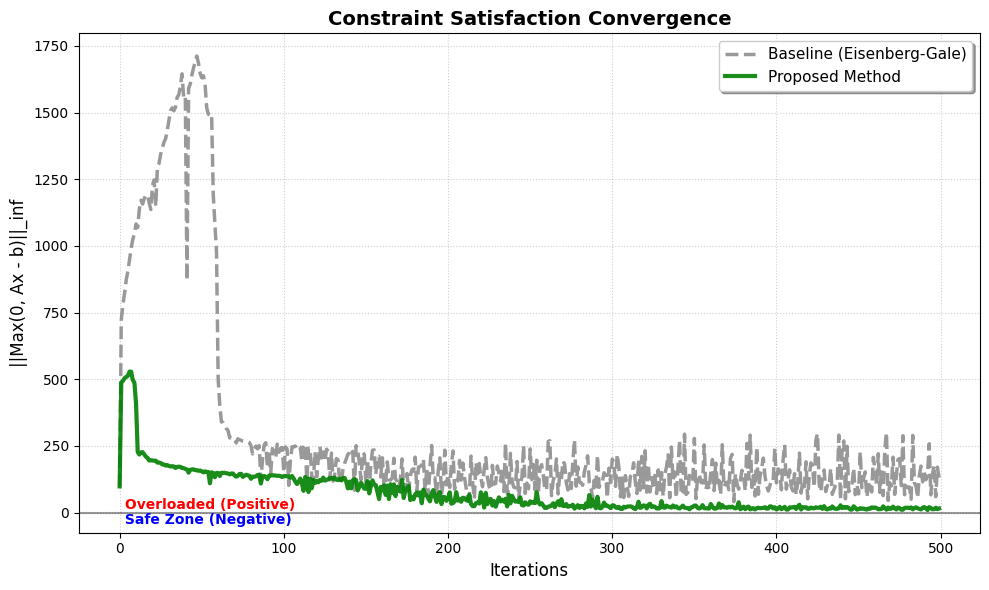

In [ ]:
for i in range(len(seed_list)):
    hist_base = res_list[-1][0]
    hist_full = res_list[-1][1]
    print("\nĐang vẽ biểu đồ...")
    plot_constraint_violation(hist_base, hist_full, log_freq=1)

In [ ]:
# --- 2. CHẠY CÁC THUẬT TOÁN ---
N_USERS, M_GOODS = valuations.shape
res_list = []
T_SLOTS = 10
A = A_matrix
a_dummy = np.zeros_like(A_matrix)
capacity_b = np.random.uniform(1, 2, T_SLOTS)
b_dummy = np.zeros_like(capacity_b)
q0 = np.zeros(T_SLOTS) # Vector độ dài 10
seed_list = [1]
for i in seed_list:
    np.random.seed(i)
    # 1. Tạo tham số ngẫu nhiên
    budget = np.random.uniform(5, 20, N_USERS)
    supply_s = np.random.uniform(5, 10, M_GOODS)

    # 2. Tạo Capacity (Sửa lỗi Capacity quá nhỏ)

    capacity_b = np.random.uniform(1, 2, T_SLOTS)
    # 1. Running Baseline
    # - Thuật toán thấy: a_dummy, b_dummy (Không bị ràng buộc)
    # - Metric tính trên: A_matrix, capacity_b (Ràng buộc thật)
    print("1. Running Baseline...")
    hist_base = full_grad_descent(
        a_dummy, b_dummy, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0, num_iters=1000, update_q=False,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    # 2. Running Proposed Full
    # - Thuật toán thấy: A_matrix, capacity_b
    # - Metric tính trên: A_matrix, capacity_b
    print("2. Running Proposed Full...")
    hist_full = full_grad_descent(
        A_matrix, capacity_b, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0.01, num_iters=1000, update_q=True,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    res_list.append([hist_base, hist_full])

1. Running Baseline...
Iter 50: Violation = 1630.8535
Iter 100: Violation = 230.4209
Iter 150: Violation = 112.9378
Iter 200: Violation = 177.2227
Iter 250: Violation = 138.5448
Iter 300: Violation = 91.1271
Iter 350: Violation = 139.2052
Iter 400: Violation = 92.7676
Iter 450: Violation = 78.7677
Iter 500: Violation = 83.5774
Iter 550: Violation = 203.3585
Iter 600: Violation = 172.6358
Iter 650: Violation = 109.8588
Iter 700: Violation = 103.9177
Iter 750: Violation = 127.6541
Iter 800: Violation = 158.8688
Iter 850: Violation = 224.6757
Iter 900: Violation = 142.5605
Iter 950: Violation = 117.1864
Iter 1000: Violation = 283.7574
2. Running Proposed Full...
Iter 50: Violation = 135.8809
Iter 100: Violation = 128.9040
Iter 150: Violation = 107.9578
Iter 200: Violation = 36.8985
Iter 250: Violation = 32.2937
Iter 300: Violation = 17.5760
Iter 350: Violation = 18.7422
Iter 400: Violation = 13.3486
Iter 450: Violation = 13.5599
Iter 500: Violation = 13.1707
Iter 550: Violation = 12.6406



Đang vẽ biểu đồ...


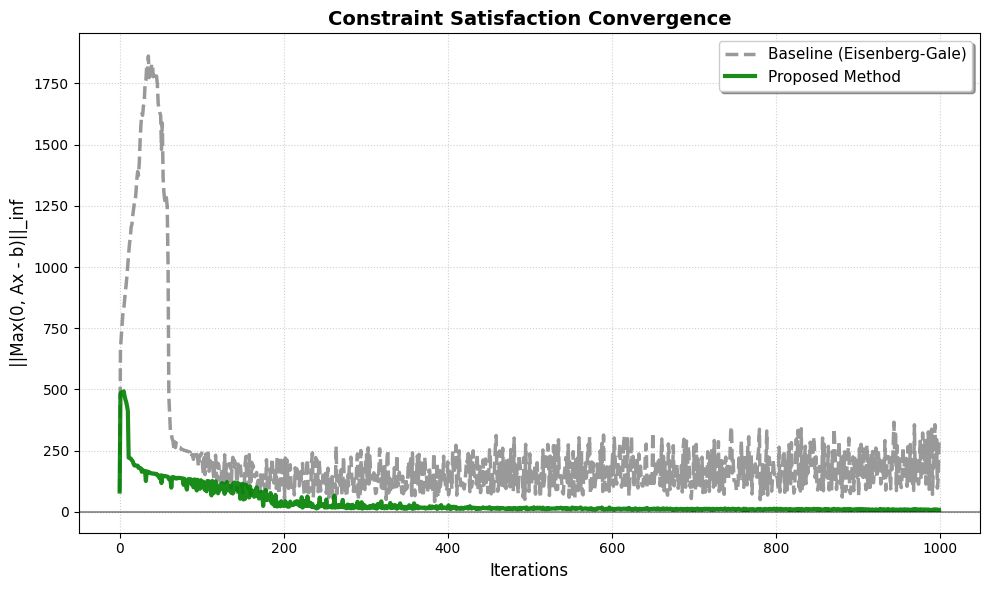

In [ ]:
for i in range(len(seed_list)):
    hist_base = res_list[-1][0]
    hist_full = res_list[-1][1]
    print("\nĐang vẽ biểu đồ...")
    plot_constraint_violation(hist_base, hist_full, log_freq=1)

In [ ]:
# --- 2. CHẠY CÁC THUẬT TOÁN ---
N_USERS, M_GOODS = valuations.shape

T_SLOTS = 10
A = A_matrix
a_dummy = np.zeros_like(A_matrix)
b_dummy = np.zeros_like(capacity_b)
q0 = np.zeros(T_SLOTS) # Vector độ dài 10
seed_list = [1]
for i in seed_list:
    np.random.seed(i)
    # 1. Tạo tham số ngẫu nhiên
    budget = np.random.uniform(5.0, 20.0, N_USERS)
    supply_s = np.random.uniform(5, 10, M_GOODS)

    # 2. Tạo Capacity (Sửa lỗi Capacity quá nhỏ)

    capacity_b = np.random.uniform(1, 2, T_SLOTS)
    # 1. Running Baseline
    # - Thuật toán thấy: a_dummy, b_dummy (Không bị ràng buộc)
    # - Metric tính trên: A_matrix, capacity_b (Ràng buộc thật)
    print("1. Running Baseline...")
    hist_base = full_grad_descent(
        a_dummy, b_dummy, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0.0, num_iters=300, update_q=False,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    # 2. Running Proposed Full
    # - Thuật toán thấy: A_matrix, capacity_b
    # - Metric tính trên: A_matrix, capacity_b
    print("2. Running Proposed Full...")
    hist_full = full_grad_descent(
        A_matrix, capacity_b, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0.01, num_iters=300, update_q=True,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    res_list.append([hist_base, hist_full])

1. Running Baseline...
Iter 50: Violation = 1630.8535
Iter 100: Violation = 230.4209
Iter 150: Violation = 112.9378
Iter 200: Violation = 177.2227
Iter 250: Violation = 138.5448
Iter 300: Violation = 91.1271
2. Running Proposed Full...
Iter 50: Violation = 135.8809
Iter 100: Violation = 128.9040
Iter 150: Violation = 107.9578
Iter 200: Violation = 36.8985
Iter 250: Violation = 32.2937
Iter 300: Violation = 17.5760


In [ ]:
for i in range(len(seed_list)):
    hist_base = res_list[3][0]
    hist_full = res_list[3][1]
    print("\nĐang vẽ biểu đồ...")
    plot_constraint_violation(hist_base, hist_full, log_freq=1,
    xlim=300)

IndexError: list index out of range

In [ ]:
# --- 2. CHẠY CÁC THUẬT TOÁN ---
N_USERS, M_GOODS = valuations.shape

T_SLOTS = 10
A = A_matrix
a_dummy = np.zeros_like(A_matrix)
b_dummy = np.zeros_like(capacity_b)
q0 = np.zeros(T_SLOTS) # Vector độ dài 10
seed_list = [5]
for i in seed_list:
    np.random.seed(i)
    # 1. Tạo tham số ngẫu nhiên
    budget = np.random.uniform(5.0, 20.0, N_USERS)
    supply_s = np.random.uniform(5, 10, M_GOODS)

    # 2. Tạo Capacity (Sửa lỗi Capacity quá nhỏ)

    capacity_b = np.random.uniform(1, 2, T_SLOTS)
    # 1. Running Baseline
    # - Thuật toán thấy: a_dummy, b_dummy (Không bị ràng buộc)
    # - Metric tính trên: A_matrix, capacity_b (Ràng buộc thật)
    print("1. Running Baseline...")
    hist_base = full_grad_descent(
        a_dummy, b_dummy, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0.0, num_iters=500, update_q=False,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    # 2. Running Proposed Full
    # - Thuật toán thấy: A_matrix, capacity_b
    # - Metric tính trên: A_matrix, capacity_b
    print("2. Running Proposed Full...")
    hist_full = full_grad_descent(
        A_matrix, capacity_b, supply_s, q0, valuations, budget, p0,
        lr_p=0.01, lr_q=0.01, num_iters=500, update_q=True,
        A_true=A_matrix, b_true=capacity_b  # <--- QUAN TRỌNG
    )

    res_list.append([hist_base, hist_full])

1. Running Baseline...
Iter 50: Violation = 1476.6818
Iter 100: Violation = 254.4329
Iter 150: Violation = 147.4874
Iter 200: Violation = 94.8602
Iter 250: Violation = 169.3135
Iter 300: Violation = 123.7311
Iter 350: Violation = 290.7098
Iter 400: Violation = 237.1850
Iter 450: Violation = 302.9494
Iter 500: Violation = 298.7987
2. Running Proposed Full...
Iter 50: Violation = 150.9219
Iter 100: Violation = 69.4683
Iter 150: Violation = 94.9894
Iter 200: Violation = 31.1379
Iter 250: Violation = 40.3220
Iter 300: Violation = 19.9433
Iter 350: Violation = 17.9522
Iter 400: Violation = 23.8050
Iter 450: Violation = 15.8837
Iter 500: Violation = 12.2693



Đang vẽ biểu đồ...


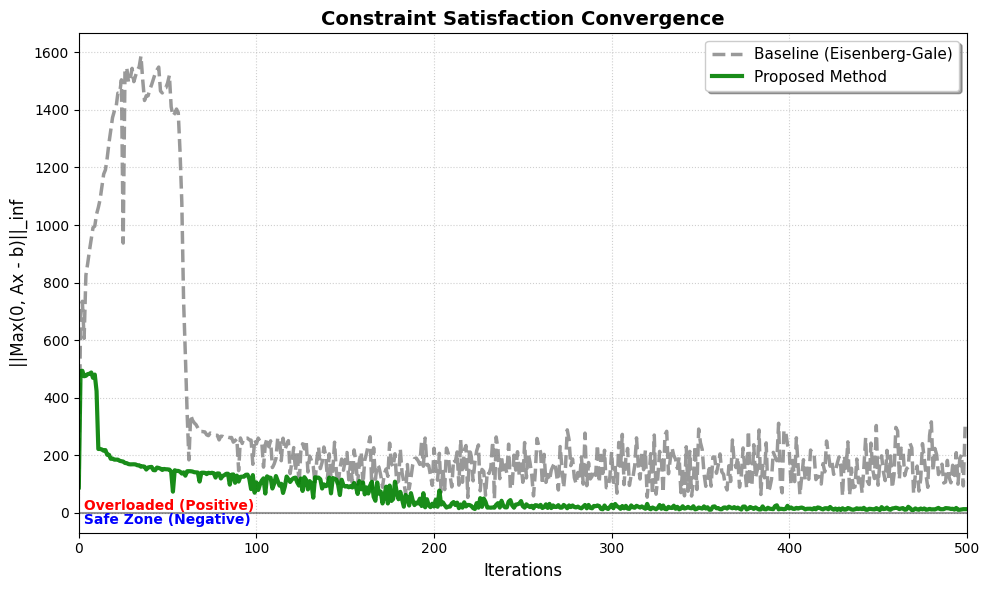

In [ ]:
for i in range(len(seed_list)):
    hist_base = res_list[4][0]
    hist_full = res_list[4][1]
    print("\nĐang vẽ biểu đồ...")
    plot_constraint_violation(hist_base, hist_full, log_freq=1,
    xlim=500)